# Pünktlichkeit am Frankfurter Hauptbahnhof

Analyse der Verspätungen der Deutschen Bahn am Frankfurt (Main) Hbf in der Woche vom 6. bis 12. Oktober 2025.

**Fragen:**
1. Wie viele Züge sind pünktlich?
2. Welche Zuggruppe ist am unpünktlichsten?
3. Zu welcher Uhrzeit gibt es die meisten Verspätungen?

**Daten:** piebro/deutsche-bahn-data (HuggingFace), Oktober 2025, Lizenz CC BY 4.0

**Technologies:** Python, DuckDB (SQL)

In [1]:
import duckdb
print("Hallo, DuckDb funktioniert gut.")

Hallo, DuckDb funktioniert gut.


## 1. Daten laden und erster Überblick

Die Datei enthält alle Halte an ca. 100 großen Bahnhöfen im Oktober 2025. Jede Zeile ist ein Halt eines Zuges an einem Bahnhof.


In [2]:
duckdb.sql("SELECT COUNT(*) FROM '../data/data-2025-10.parquet'")


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      1989180 │
└──────────────┘

In [3]:
duckdb.sql("select * from '../data/data-2025-10.parquet' limit 5")


┌──────────────────────┬──────────────────────┬──────────┬──────────────┬─────────────┬───────────────────────────┬──────────────┬─────────────────────┬─────────────────────┬───────────────────────┬────────────┬──────────────────────┬────────────────────────┬──────────────────────┬─────────────────────┬────────────────────────┬───────────────────────┬────────────────────────────────────┐
│     station_name     │   xml_station_name   │   eva    │ train_number │ line_number │ final_destination_station │ delay_in_min │        time         │ arrival_is_canceled │ departure_is_canceled │ train_type │  train_line_ride_id  │ train_line_station_num │ arrival_planned_time │ arrival_change_time │ departure_planned_time │ departure_change_time │                 id                 │
│       varchar        │       varchar        │ varchar  │   varchar    │   varchar   │          varchar          │    int32     │    timestamp_ns     │       boolean       │        boolean        │  varchar   │       

In [4]:
duckdb.sql("""
    select station_name, count(*) as anzahl
    from '../data/data-2025-10.parquet'
    group by station_name
    order by  anzahl DESC
    limit 20

""")

┌────────────────────────────┬────────┐
│        station_name        │ anzahl │
│          varchar           │ int64  │
├────────────────────────────┼────────┤
│ Berlin Ostkreuz            │  64476 │
│ München Hbf                │  64355 │
│ Frankfurt (Main) Hbf       │  60842 │
│ Hamburg Hbf                │  59866 │
│ Berlin Friedrichstraße     │  49005 │
│ Stuttgart Hbf              │  48001 │
│ Düsseldorf Hbf             │  45821 │
│ Berlin Hauptbahnhof        │  44992 │
│ Berlin Ostbahnhof          │  40509 │
│ Köln Hbf                   │  38906 │
│ Berlin Gesundbrunnen       │  37814 │
│ Hamburg-Altona             │  37613 │
│ Berlin Südkreuz            │  36477 │
│ München Ost                │  34648 │
│ Dortmund Hbf               │  33513 │
│ Köln Messe/Deutz           │  32614 │
│ Nürnberg Hbf               │  32068 │
│ München-Pasing             │  31498 │
│ Berlin Zoologischer Garten │  30544 │
│ Hannover Hbf               │  30531 │
└────────────────────────────┴────────┘


## 2. Auswahl der Daten

Für die Analyse wird eine View `frankfurt` erstellt:
- nur **Frankfurt (Main) Hbf**
- nur die Woche **Montag, 6. bis Sonntag, 12. Oktober 2025**

Zusätzliche Spalten:
- `datum` und `wochentag`: um die Ergebnisse Tag für Tag zu vergleichen
- `zuggruppe`: fasst die Zugtypen zu Fernverkehr, Regionalverkehr und S-Bahn zusammen


In [5]:
duckdb.sql("""
      CREATE OR REPLACE VIEW frankfurt AS
      SELECT
           *,
           CAST(time AS DATE) AS datum,
           dayname(time) AS wochentag,
           hour(time) AS stunde,
           CASE
               WHEN train_type IN ('ICE', 'IC', 'EC', 'ECE', 'TGV','NJ' ) THEN 'Fernverkehr'
               WHEN train_type IN ('RE', 'RB', 'HLB', 'VIA', 'STN' ) THEN 'Regionalverkehr'
               WHEN train_type = 'S' THEN 'S-Bahn'
               ELSE 'Sonstige'
           END AS zuggruppe           
      FROM '../data/data-2025-10.parquet'
      WHERE station_name = 'Frankfurt (Main) Hbf'
            and time >= '2025-10-06'  
            and time <  '2025-10-13'  


""")

In [6]:
duckdb.sql("""
      SELECT zuggruppe, COUNT(*) AS anzahl
      FROM frankfurt
      GROUP BY zuggruppe
      ORDER BY anzahl DESC

""")

┌─────────────────┬────────┐
│    zuggruppe    │ anzahl │
│     varchar     │ int64  │
├─────────────────┼────────┤
│ S-Bahn          │   5979 │
│ Regionalverkehr │   5213 │
│ Fernverkehr     │   1863 │
└─────────────────┴────────┘

## 3. Datenqualität und Überblick

Bevor die Fragen beantwortet werden, wird geprüft, ob es Daten gibt, die nicht mitgezählt werden dürfen: ausgefallene Halte, Busse und unrealistische Werte.


In [7]:
duckdb.sql("""
     select
       count(*) as gesamt,
       sum(case when arrival_is_canceled or departure_is_canceled then 1 else 0 end) as ausgefallen,
       sum(case when train_type = 'Bus' then 1 else 0 end) as busse,
       sum(case when delay_in_min < 0 then 1 else 0 end) as zu_frueh
    from frankfurt

""")

┌────────┬─────────────┬────────┬──────────┐
│ gesamt │ ausgefallen │ busse  │ zu_frueh │
│ int64  │   int128    │ int128 │  int128  │
├────────┼─────────────┼────────┼──────────┤
│  13055 │         552 │      0 │      380 │
└────────┴─────────────┴────────┴──────────┘

In [8]:
duckdb.sql("""
     SELECT train_type, COUNT(*) AS anzahl
     FROM frankfurt
     GROUP BY train_type
     ORDER BY anzahl DESC 
""")

┌────────────┬────────┐
│ train_type │ anzahl │
│  varchar   │ int64  │
├────────────┼────────┤
│ S          │   5979 │
│ RE         │   1780 │
│ ICE        │   1636 │
│ RB         │   1582 │
│ HLB        │    933 │
│ VIA        │    878 │
│ IC         │    144 │
│ TGV        │     42 │
│ STN        │     40 │
│ NJ         │     14 │
│ EC         │     14 │
│ ECE        │     13 │
└────────────┴────────┘
  12 rows   2 columns

In [9]:
duckdb.sql("DESCRIBE frankfurt")

┌───────────────────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│        column_name        │ column_type  │  null   │   key   │ default │  extra  │
│          varchar          │   varchar    │ varchar │ varchar │ varchar │ varchar │
├───────────────────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ station_name              │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ xml_station_name          │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ eva                       │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ train_number              │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ line_number               │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ final_destination_station │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ delay_in_min              │ INTEGER      │ YES     │ NULL    │ NULL    │ NULL    │
│ time                      │ TIMESTAMP_NS │ YES     │ NULL    │ 

In [10]:
duckdb.sql("SELECT * FROM frankfurt LIMIT 20").df()

,station_name,xml_station_name,eva,train_number,line_number,final_destination_station,delay_in_min,time,arrival_is_canceled,departure_is_canceled,...,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time,id,datum,wochentag,stunde,zuggruppe
0,Frankfurt (Main) Hbf,Frankfurt Hbf (tief),08098105,35353,3,Frankfurt(Main)Süd,0,2025-10-12 17:07:00,False,False,...,12,2025-10-12 17:06:00,2025-10-12 17:06:00,2025-10-12 17:07:00,2025-10-12 17:07:00,-6206125121047020629-2510121641-12,2025-10-12,Sunday,17,S-Bahn
1,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,35754,7,Frankfurt (Main) Hbf,2,2025-10-12 17:07:00,False,False,...,10,2025-10-12 17:05:00,2025-10-12 17:07:00,NaT,NaT,-440030555796431522-2510121626-10,2025-10-12,Sunday,17,S-Bahn
2,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,15327,68,Heidelberg Hbf,2,2025-10-12 17:08:00,False,False,...,1,NaT,NaT,2025-10-12 17:06:00,2025-10-12 17:08:00,-550877265853838045-2510121706-1,2025-10-12,Sunday,17,Regionalverkehr
3,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,15427,67,Schwetzingen,2,2025-10-12 17:08:00,False,False,...,1,NaT,NaT,2025-10-12 17:06:00,2025-10-12 17:08:00,-4572582475533958702-2510121706-1,2025-10-12,Sunday,17,Regionalverkehr
4,Frankfurt (Main) Hbf,Frankfurt Hbf (tief),08098105,35255,2,Frankfurt (Main) Hbf,1,2025-10-12 17:09:00,False,False,...,13,2025-10-12 17:08:00,2025-10-12 17:09:00,NaT,NaT,7541221389331823768-2510121633-13,2025-10-12,Sunday,17,S-Bahn
5,Frankfurt (Main) Hbf,Frankfurt Hbf (tief),08098105,35352,3,Bad Soden(Taunus),0,2025-10-12 17:09:00,False,False,...,7,2025-10-12 17:08:00,2025-10-12 17:07:00,2025-10-12 17:09:00,2025-10-12 17:09:00,7580878547322654532-2510121658-7,2025-10-12,Sunday,17,S-Bahn
6,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,4263,2,Frankfurt (Main) Hbf,24,2025-10-12 17:12:00,False,False,...,13,2025-10-12 16:48:00,2025-10-12 17:12:00,NaT,NaT,-2052222982576990269-2510121504-13,2025-10-12,Sunday,17,Regionalverkehr
7,Frankfurt (Main) Hbf,Frankfurt Hbf (tief),08098105,35152,1,Wiesbaden Hbf,0,2025-10-12 17:12:00,False,False,...,7,2025-10-12 17:11:00,2025-10-12 17:10:00,2025-10-12 17:12:00,2025-10-12 17:12:00,-1488543395788965775-2510121700-7,2025-10-12,Sunday,17,S-Bahn
8,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,596,NaN,Berlin Hbf,59,2025-10-12 17:13:00,False,False,...,7,2025-10-12 16:08:00,2025-10-12 17:08:00,2025-10-12 16:14:00,2025-10-12 17:13:00,4083739950560377043-2510121246-7,2025-10-12,Sunday,17,Fernverkehr
9,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,4577,70,Mannheim Hbf,1,2025-10-12 17:13:00,False,False,...,1,NaT,NaT,2025-10-12 17:12:00,2025-10-12 17:13:00,285495907267466255-2510121712-1,2025-10-12,Sunday,17,Regionalverkehr


In [11]:
duckdb.sql("""
     SELECT * FROM frankfurt
     ORDER BY delay_in_min DESC
     LIMIT 10
""").df()

,station_name,xml_station_name,eva,train_number,line_number,final_destination_station,delay_in_min,time,arrival_is_canceled,departure_is_canceled,...,train_line_station_num,arrival_planned_time,arrival_change_time,departure_planned_time,departure_change_time,id,datum,wochentag,stunde,zuggruppe
0,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,403,NaN,Zürich HB,174,2025-10-12 05:39:00,True,True,...,8,2025-10-12 02:20:00,2025-10-12 05:22:00,2025-10-12 02:45:00,2025-10-12 05:39:00,-5851721557238592488-2510111915-8,2025-10-12,Sunday,5,Fernverkehr
1,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,60403,NaN,Zürich HB,172,2025-10-12 05:37:00,False,False,...,8,2025-10-12 02:20:00,2025-10-12 05:20:00,2025-10-12 02:45:00,2025-10-12 05:37:00,7582314568044505717-2510111915-8,2025-10-12,Sunday,5,Fernverkehr
2,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,618,NaN,Kiel Hbf,134,2025-10-10 07:00:00,False,False,...,6,2025-10-10 04:38:00,2025-10-10 06:10:00,2025-10-10 04:46:00,2025-10-10 07:00:00,2686007473625185344-2510092313-6,2025-10-10,Friday,7,Fernverkehr
3,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,15442,67,Frankfurt (Main) Hbf,129,2025-10-12 01:57:00,False,False,...,15,2025-10-11 23:48:00,2025-10-12 01:57:00,NaT,NaT,-4369812750746541737-2510112246-15,2025-10-12,Sunday,1,Regionalverkehr
4,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,27,NaN,Wien Hbf,128,2025-10-10 14:30:00,False,False,...,11,2025-10-10 12:12:00,2025-10-10 14:25:00,2025-10-10 12:22:00,2025-10-10 14:30:00,-1790024725878292801-2510100823-11,2025-10-10,Friday,14,Fernverkehr
5,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,403,NaN,Zürich HB,120,2025-10-07 04:45:00,False,False,...,9,2025-10-07 02:20:00,2025-10-07 03:42:00,2025-10-07 02:45:00,2025-10-07 04:45:00,-5851721557238592488-2510061915-9,2025-10-07,Tuesday,4,Fernverkehr
6,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,112,NaN,Frankfurt (Main) Hbf,114,2025-10-07 21:34:00,False,False,...,23,2025-10-07 19:40:00,2025-10-07 21:34:00,NaT,NaT,2979813652439599907-2510071042-23,2025-10-07,Tuesday,21,Fernverkehr
7,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,9553,NaN,Frankfurt (Main) Hbf,108,2025-10-09 18:47:00,False,False,...,5,2025-10-09 16:59:00,2025-10-09 18:47:00,NaT,NaT,2182708515882328076-2510091310-5,2025-10-09,Thursday,18,Fernverkehr
8,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,60403,NaN,Zürich HB,106,2025-10-07 04:31:00,False,False,...,9,2025-10-07 02:20:00,2025-10-07 03:42:00,2025-10-07 02:45:00,2025-10-07 04:31:00,7582314568044505717-2510061915-9,2025-10-07,Tuesday,4,Fernverkehr
9,Frankfurt (Main) Hbf,Frankfurt(Main)Hbf,08000105,4634,54,Frankfurt (Main) Hbf,104,2025-10-09 01:28:00,False,False,...,32,2025-10-08 23:44:00,2025-10-09 01:28:00,NaT,NaT,1556741539828157941-2510082135-32,2025-10-09,Thursday,1,Regionalverkehr


In [12]:
duckdb.sql("""
     SELECT delay_in_min, COUNT(*)AS anzahl
     FROM frankfurt
     WHERE delay_in_min < 0
     GROUP BY delay_in_min
     ORDER BY delay_in_min
""")

┌──────────────┬────────┐
│ delay_in_min │ anzahl │
│    int32     │ int64  │
├──────────────┼────────┤
│           -8 │      1 │
│           -7 │      3 │
│           -6 │      2 │
│           -5 │     13 │
│           -4 │     15 │
│           -3 │     32 │
│           -2 │     69 │
│           -1 │    245 │
└──────────────┴────────┘

In [13]:
duckdb.sql("""
     PIVOT (
         SELECT train_type, (-delay_in_min) || 'Min. zu fruh' AS minuten 
         FROM frankfurt 
         WHERE delay_in_min < 0
     )

     ON minuten
     USING COUNT(*)
     GROUP BY train_type
     ORDER BY train_type
""").df()

,train_type,1Min. zu fruh,2Min. zu fruh,3Min. zu fruh,4Min. zu fruh,5Min. zu fruh,6Min. zu fruh,7Min. zu fruh,8Min. zu fruh
0,ECE,3,0,0,0,0,0,0,0
1,HLB,7,3,5,6,3,0,1,1
2,IC,1,0,0,1,2,0,0,0
3,ICE,39,18,5,1,3,1,1,0
4,RB,61,16,6,1,0,0,0,0
5,RE,63,20,9,3,2,0,0,0
6,S,43,1,0,0,0,0,0,0
7,STN,2,2,0,0,0,0,0,0
8,VIA,26,9,7,3,3,1,1,0


**Pivot-Tabelle: zu frühe Halte nach Zugtyp**

So liest man die Tabelle:
- **Zeilen:** Zugtyp
- **Spalten:** wie viele Minuten der Zug zu früh war
- **Werte:** Anzahl der Halte

Beispiel: In der Zeile `ICE` und der Spalte für 2 Minuten steht 18. Das heißt: 18 ICE-Halte waren 2 Minuten zu früh.

**Was die Tabelle zeigt**
- Die meisten Züge waren nur **1 Minute** zu früh.
- Die S-Bahn war fast nie mehr als 1 Minute zu früh (43 von 44 Halten).
- Der größte Wert ist **8 Minuten** (1 Halt, HLB).

In [14]:
duckdb.sql("""
       SELECT datum, wochentag, COUNT(*) AS anzahl
       FROM frankfurt
       GROUP BY datum, wochentag
       ORDER BY datum
""")

┌────────────┬───────────┬────────┐
│   datum    │ wochentag │ anzahl │
│    date    │  varchar  │ int64  │
├────────────┼───────────┼────────┤
│ 2025-10-06 │ Monday    │   1927 │
│ 2025-10-07 │ Tuesday   │   1942 │
│ 2025-10-08 │ Wednesday │   1951 │
│ 2025-10-09 │ Thursday  │   1955 │
│ 2025-10-10 │ Friday    │   1935 │
│ 2025-10-11 │ Saturday  │   1717 │
│ 2025-10-12 │ Sunday    │   1628 │
└────────────┴───────────┴────────┘

## 4. Frage 1: Wie viele Züge sind pünktlich?

Definition der Deutschen Bahn: Ein Zug ist pünktlich, wenn er weniger als 6 Minuten Verspätung hat (`delay_in_min <= 5`). Ausgefallene Halte werden nicht mitgezählt.


In [15]:
duckdb.sql("""
    SELECT 
      COUNT(*) AS gesamt,
      SUM(CASE WHEN delay_in_min <= 5 THEN 1 ELSE 0 END) AS puenktlich,
      ROUND(100.0 * SUM(CASE WHEN delay_in_min <= 5 THEN 1 ELSE 0 END) / COUNT(*) , 1) AS prozent
    FROM frankfurt
    WHERE NOT arrival_is_canceled
      AND NOT departure_is_canceled
        
""")

┌────────┬────────────┬─────────┐
│ gesamt │ puenktlich │ prozent │
│ int64  │   int128   │ double  │
├────────┼────────────┼─────────┤
│  12503 │       9494 │    75.9 │
└────────┴────────────┴─────────┘

In [16]:
duckdb.sql("""
     SELECT 
       datum,
       wochentag,
       COUNT(*) AS gesamt,
       COUNT_IF(delay_in_min <= 5 ) AS puenktlich,
       COUNT_IF(delay_in_min >= 6 ) AS verspeatet,
       ROUND(100.0 * SUM(CASE WHEN delay_in_min <= 5 THEN 1 ELSE 0 END) / COUNT(*) ,1) AS prozent_pkt
     FROM frankfurt
     WHERE NOT arrival_is_canceled
       AND NOT departure_is_canceled
     GROUP BY datum, wochentag
     ORDER BY datum    
""").df()

,datum,wochentag,gesamt,puenktlich,verspeatet,prozent_pkt
0,2025-10-06,Monday,1828,1284.0,544.0,70.2
1,2025-10-07,Tuesday,1868,1395.0,473.0,74.7
2,2025-10-08,Wednesday,1830,1307.0,523.0,71.4
3,2025-10-09,Thursday,1880,1389.0,491.0,73.9
4,2025-10-10,Friday,1823,1351.0,472.0,74.1
5,2025-10-11,Saturday,1697,1382.0,315.0,81.4
6,2025-10-12,Sunday,1577,1386.0,191.0,87.9


**Ergebnis Frage 1**
- In der Woche waren **75,9 %** der Halte pünktlich. Etwa jeder vierte Zug hatte 6 Minuten oder mehr Verspätung.
- Zusätzlich sind **4,2 %** der Halte ausgefallen.
- Am schlechtesten war **Montag** (70,2 %), am besten **Sonntag** (87,9 %).
- Unter der Woche liegt die Pünktlichkeit bei 70–75 %, am Wochenende bei 81–88 %.
- Mögliche Erklärung (Hypothese): Unter der Woche fahren mehr Züge (ca. 1.930–1.955 pro Tag, am Wochenende 1.628–1.717). Verspätungen übertragen sich dann leichter. Die Daten zeigen den Grund aber nicht.


##  Frage 2: Welche Züge haben die meisten Verspätungen?

Ich vergleiche drei Gruppen: Fernverkehr, Regionalverkehr und S-Bahn.

In [17]:
df_gruppen = duckdb.sql("""
    SELECT zuggruppe,
      COUNT (*) AS gesamt,
      COUNT(*) FILTER (WHERE delay_in_min <= 5) AS puenktlich,
      ROUND(100.0 * COUNT (*) FILTER(WHERE delay_in_min <= 5)/COUNT(*) ,1) AS prozent_pkt,
      ROUND(AVG(delay_in_min),1) AS mittlere_verspaetung
    FROM frankfurt
    WHERE NOT arrival_is_canceled
     AND NOT departure_is_canceled
    GROUP BY zuggruppe
    ORDER BY prozent_pkt ASC  



""").df()

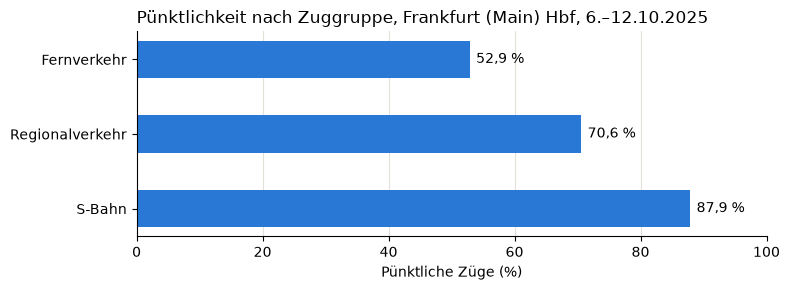

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))

ax.barh(df_gruppen["zuggruppe"], df_gruppen["prozent_pkt"], color="#2a78d6", height=0.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Pünktliche Züge (%)")
ax.set_title("Pünktlichkeit nach Zuggruppe, Frankfurt (Main) Hbf, 6.–12.10.2025", loc="left")

for i, wert in enumerate(df_gruppen["prozent_pkt"]):
    ax.text(wert + 1, i, f"{wert} %".replace(".", ","), va="center")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e1e0d9")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../grafiken/frage2_zuggruppen.png", dpi=150)
plt.show()


**Ergebnis**
- Der Fernverkehr ist am unpünktlichsten im Zeitraum von 06.10.2025 bis 12.10.2025. 
- Nur 52,9 % der Fernzüge waren pünktlich.
- Die Gruppe von S-Bahn ist am pünktlichsten.

In [19]:
duckdb.sql("""
    PIVOT frankfurt     
    ON datum
    USING COUNT(*) 
    GROUP BY stunde
    ORDER BY stunde
""").df()

,stunde,2025-10-06,2025-10-07,2025-10-08,2025-10-09,2025-10-10,2025-10-11,2025-10-12
0,0,38,57,53,55,54,54,55
1,1,20,19,21,31,22,32,41
2,2,3,6,6,7,5,30,27
3,3,8,4,6,9,7,24,19
4,4,43,45,41,41,43,34,32
5,5,73,74,73,74,68,55,42
6,6,99,101,101,104,104,64,54
7,7,116,115,112,112,109,78,65
8,8,110,107,111,106,112,82,77
9,9,98,102,103,104,101,79,78


In [20]:
df_stunden = duckdb.sql("""
       
      SELECT 
         stunde, 
         COUNT(*) AS gesamt,
         COUNT(*) FILTER (WHERE delay_in_min >=6) AS verspaetet,
         ROUND(100.0 * COUNT(*) FILTER (WHERE delay_in_min >=6) / COUNT(*),1) AS prozent_verspaetet,
         ROUND(AVG(delay_in_min),1) AS mittlere_verspaetung,

      FROM frankfurt
      WHERE NOT arrival_is_canceled
        AND NOT departure_is_canceled
      GROUP BY stunde
      ORDER BY stunde  


""").df()

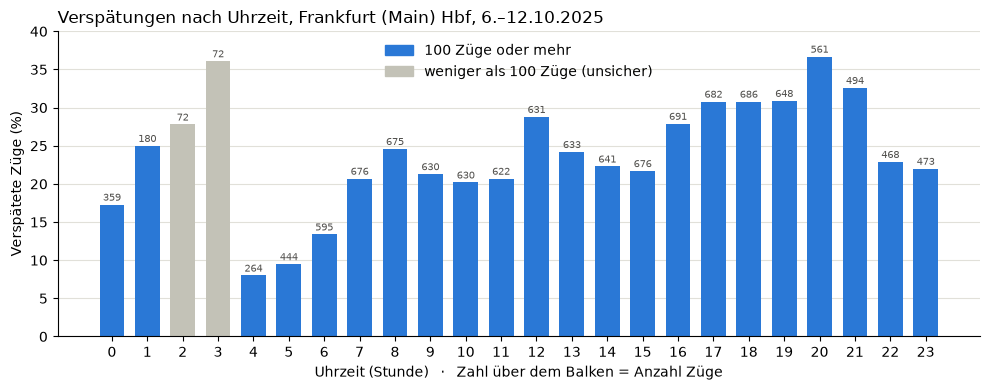

In [21]:
from matplotlib.patches import Patch

farben = ["#c3c2b7" if n < 100 else "#2a78d6" for n in df_stunden["gesamt"]]

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_stunden["stunde"], df_stunden["prozent_verspaetet"], color=farben, width=0.7)

for stunde, wert, anzahl in zip(df_stunden["stunde"], df_stunden["prozent_verspaetet"], df_stunden["gesamt"]):
    ax.text(stunde, wert + 0.5, anzahl, ha="center", fontsize=7, color="#52514e")

ax.set_xticks(range(24))
ax.set_ylim(0, 40)
ax.set_xlabel("Uhrzeit (Stunde)   ·   Zahl über dem Balken = Anzahl Züge")
ax.set_ylabel("Verspätete Züge (%)")
ax.set_title("Verspätungen nach Uhrzeit, Frankfurt (Main) Hbf, 6.–12.10.2025", loc="left")

ax.legend(
    handles=[
        Patch(color="#2a78d6", label="100 Züge oder mehr"),
        Patch(color="#c3c2b7", label="weniger als 100 Züge (unsicher)"),
    ],
    loc="upper center",
    frameon=False,
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../grafiken/frage3_stunden.png", dpi=150)
plt.show()


**Ergebnis**
- Um 20 Uhr gibt es die meisten Verspätungen: 36,7 % der Züge waren verspätet.
- Am Abend (17 bis 21 Uhr) sind die Züge am unpünktlichsten.
- Am frühen Morgen (4 bis 6 Uhr) sind die Züge am pünktlichsten, weniger als 15 % waren verspätet.
- Graue Balken: Um 2 und 3 Uhr fahren nur wenige Züge. Diese Werte sind nicht so sicher.
- Ich denke, die Verspätungen werden im Laufe des Tages größer, weil eine Verspätung auch die nächsten Züge später macht.